In [1]:
import os
import numpy as np
import pickle
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import csv
from nilearn import plotting
from nilearn.image import resample_img
from nilearn.image import math_img
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from glob import glob
import nilearn.image as nlimg
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

from scipy.stats import spearmanr
from tqdm import tqdm
# from rsatoolbox.data.dataset import Dataset
# from rsatoolbox.rdm.calc import calc_rdm
# from rsatoolbox.rdm import RDMs
import seaborn as sns
from sklearn.metrics import pairwise_distances
import copy

In [2]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [3]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

In [4]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

# Jacarrd index

In [20]:
import nibabel as nib
import numpy as np

model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3":      "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4":    "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5":  "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz",
}

print(f"{'model':<12} {'nonzero':>10} {'finite_nz':>10}")
print("-" * 34)
for name in model_names:
    data = nib.load(tmap_paths[name]).get_fdata()
    flat = data.flatten()
    nonzero = int(np.sum(flat != 0))
    # NaNs count as nonzero under `!= 0`, so report the finite count too
    finite_nz = int(np.sum((flat != 0) & np.isfinite(flat)))
    print(f"{name:<12} {nonzero:>10} {finite_nz:>10}")

model           nonzero  finite_nz
----------------------------------
behavioral         1038       1038
cgpt3               592        592
claude4             619        619
gemini2p5          1236       1236


In [ ]:
import nibabel as nib
import numpy as np

model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3":      "./outputs/tBrainmap/tmap_cgpt3_p05_fisherz.nii.gz",
    "claude4":    "./outputs/tBrainmap/tmap_claude4_p05_fisherz.nii.gz",
    "gemini2p5":  "./outputs/tBrainmap/tmap_gemini2p5_p0_fisherz.nii.gz",
}

print(f"{'model':<12} {'nonzero':>10} {'finite_nz':>10}")
print("-" * 34)
for name in model_names:
    data = nib.load(tmap_paths[name]).get_fdata()
    flat = data.flatten()
    nonzero = int(np.sum(flat != 0))
    # NaNs count as nonzero under `!= 0`, so report the finite count too
    finite_nz = int(np.sum((flat != 0) & np.isfinite(flat)))
    print(f"{name:<12} {nonzero:>10} {finite_nz:>10}")

model           nonzero  finite_nz
----------------------------------
behavioral         1038       1038
cgpt3              1105       1105
claude4            1156       1156
gemini2p5          2694       2694


### Same voxel counts

model           nonzero  finite_nonzero
---------------------------------------
behavioral         1038            1038
cgpt3              1105            1105
claude4            1156            1156
gemini2p5          2694            2694
---------------------------------------
min_voxels used for fixed-count Jaccard: 1038
behavioral   selected 1038 voxels
cgpt3        selected 1038 voxels
claude4      selected 1038 voxels
gemini2p5    selected 1038 voxels


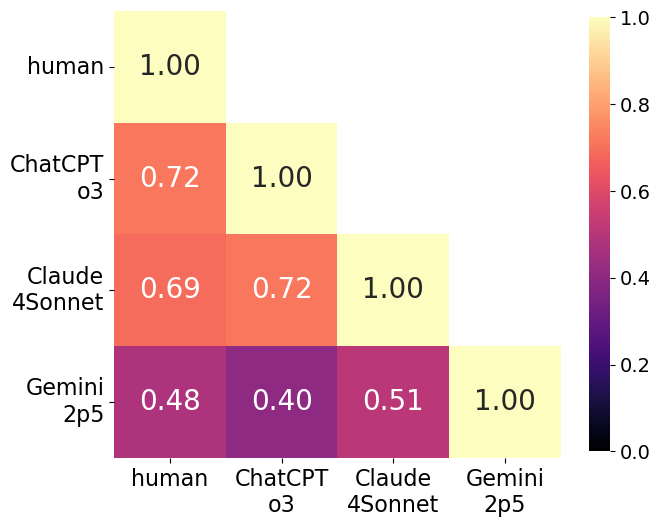

In [18]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
model_names2 = ["human", "ChatCPT_o3", "Claude_4Sonnet", "Gemini_2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p05_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p05_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p05_fisherz.nii.gz"
}

# Load all t-maps and flatten
flat_maps = {}
nonzero_counts = []
print(f"{'model':<12} {'nonzero':>10} {'finite_nonzero':>15}")
print("-" * 39)
for name in model_names:
    img = nib.load(tmap_paths[name])
    data = img.get_fdata()
    flat = data.flatten()
    # treat only finite, truly-nonzero voxels as significant (NaNs are non-sig fill)
    valid = (flat != 0) & np.isfinite(flat)
    flat = np.where(valid, flat, 0.0)   # zero out NaNs so downstream sorting is clean
    flat_maps[name] = flat

    n_nonzero = int(np.sum(data.flatten() != 0))   # raw, includes NaNs
    n_finite  = int(np.sum(valid))                 # the count we actually use
    nonzero_counts.append(n_finite)
    print(f"{name:<12} {n_nonzero:>10} {n_finite:>15}")

# minimum significant-voxel count across models -> fixed count for fair Jaccard
min_voxels = min(nonzero_counts)
print("-" * 39)
print(f"min_voxels used for fixed-count Jaccard: {min_voxels}")

# For each model, take the top `min_voxels` largest values
final_voxel_indices = {}
for name in model_names:
    flat = flat_maps[name]
    nonzero_idx = np.where(flat != 0)[0]
    nonzero_vals = flat[nonzero_idx]
    sorted_indices = nonzero_idx[np.argsort(nonzero_vals)[::-1][:min_voxels]]
    final_voxel_indices[name] = sorted_indices
    print(f"{name:<12} selected {len(sorted_indices)} voxels")

# Binary maps
binary_maps = {}
for n, name in enumerate(model_names):
    binary = np.zeros_like(flat_maps[name], dtype=int)
    binary[final_voxel_indices[name]] = 1
    binary_maps[model_names2[n]] = binary

# Jaccard matrix
jaccard_matrix = np.zeros((len(model_names2), len(model_names2)))
for i, name1 in enumerate(model_names2):
    for j, name2 in enumerate(model_names2):
        map1 = binary_maps[name1]
        map2 = binary_maps[name2]
        intersection = np.logical_and(map1, map2).sum()
        union = np.logical_or(map1, map2).sum()
        jaccard_matrix[i, j] = intersection / union if union > 0 else np.nan

def split_name(name):
    return name.replace('_', '\n')

jaccard_df = pd.DataFrame(jaccard_matrix,
                          index=[split_name(n) for n in model_names2],
                          columns=[split_name(n) for n in model_names2])

tri_mask = np.triu(np.ones_like(jaccard_df, dtype=bool), k=1)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    jaccard_df, annot=True, fmt=".2f", cmap="magma",
    vmin=0, vmax=1, square=True, cbar=True, mask=tri_mask,
    annot_kws={"size": 20}, cbar_kws={"shrink": 0.85, "aspect": 20}
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.set_position([1, .15, .03, .7])
plt.yticks(rotation=0, fontsize=16)
plt.xticks(fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
import os
import numpy as np
import nibabel as nib


output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap"
os.makedirs(output_dir, exist_ok=True)

# Load all t-maps and flatten
flat_maps = {}
nonzero_counts = []
nii_imgs = {}
for name in model_names:
    img = nib.load(tmap_paths[name])
    data = img.get_fdata()
    flat = data.flatten()
    flat_maps[name] = flat
    nii_imgs[name] = img
    nonzero_counts.append(np.sum(flat != 0))

# Find the minimum 80% count across all models (based on nonzero voxels)
eighty_counts = [int(1 * n) for n in nonzero_counts]
min_voxels = min(eighty_counts)

# For each model, get the indices of the top min_voxels largest (nonzero) values
final_voxel_indices = {}
for name in model_names:
    flat = flat_maps[name]
    nonzero_idx = np.where(flat != 0)[0]
    nonzero_vals = flat[nonzero_idx]
    # Sort nonzero values descending, take top min_voxels
    sorted_indices = nonzero_idx[np.argsort(nonzero_vals)[::-1][:min_voxels]]
    final_voxel_indices[name] = sorted_indices

# Export new nii files with only top min_voxels retained, others set to zero
for name in model_names:
    flat = flat_maps[name].copy()
    mask = np.zeros_like(flat, dtype=bool)
    mask[final_voxel_indices[name]] = True
    new_flat = np.zeros_like(flat)
    new_flat[mask] = flat[mask]
    new_data = new_flat.reshape(nii_imgs[name].shape)
    new_img = nib.Nifti1Image(new_data, nii_imgs[name].affine, nii_imgs[name].header)
    out_path = os.path.join(output_dir, f"tmap_{name}_top{min_voxels}_matched.nii.gz")
    nib.save(new_img, out_path)
    print(f"Exported: {out_path}")

Exported: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\tmap_behavioral_top1038_matched.nii.gz
Exported: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\tmap_cgpt3_top1038_matched.nii.gz
Exported: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\tmap_claude4_top1038_matched.nii.gz
Exported: N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\tBrainmap\tmap_gemini2p5_top1038_matched.nii.gz


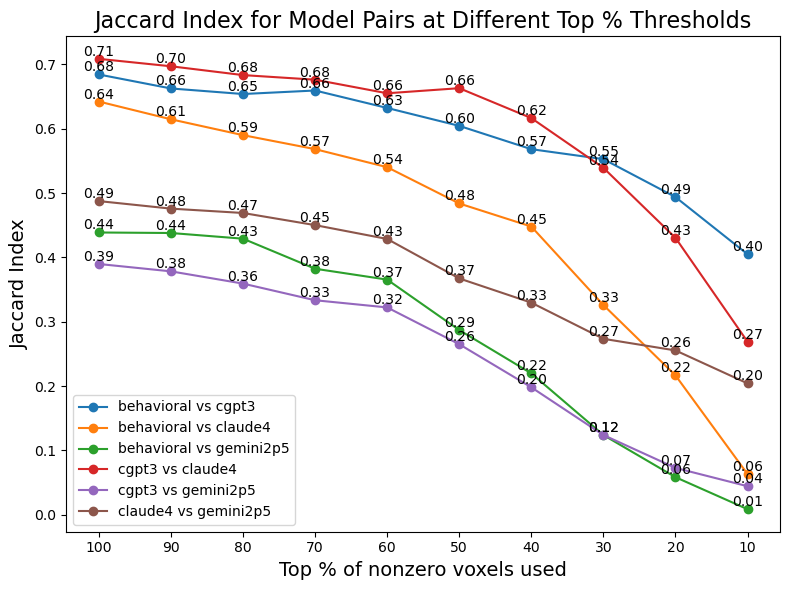

In [72]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import itertools

# Model names and paths
model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz"
}

# Load all t-maps and flatten
flat_maps = {}
nonzero_counts = []
for name in model_names:
    img = nib.load(tmap_paths[name])
    data = img.get_fdata()
    flat = data.flatten()
    flat_maps[name] = flat
    nonzero_counts.append(np.sum(flat != 0))

# Find the minimum nonzero voxel count across all models
min_nonzero = min(nonzero_counts)

# Define percentages to test (from 70% to 10%)
percentages = np.arange(100, 9, -10)

# Prepare to store Jaccard indices for each pair and each percentage
pair_names = []
for i, j in itertools.combinations(range(len(model_names)), 2):
    pair_names.append(f"{model_names[i]} vs {model_names[j]}")
jaccard_results = {pair: [] for pair in pair_names}

# For each percentage, compute Jaccard for each model pair
for perc in percentages:
    n_vox = int(min_nonzero * perc / 100)
    # Get top n_vox indices for each model
    top_voxel_indices = {}
    for name in model_names:
        flat = flat_maps[name]
        nonzero_idx = np.where(flat != 0)[0]
        nonzero_vals = flat[nonzero_idx]
        sorted_indices = nonzero_idx[np.argsort(nonzero_vals)[::-1][:n_vox]]
        top_voxel_indices[name] = set(sorted_indices)
    # Compute Jaccard for each pair
    for i, j in itertools.combinations(range(len(model_names)), 2):
        set1 = top_voxel_indices[model_names[i]]
        set2 = top_voxel_indices[model_names[j]]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        jaccard = intersection / union if union > 0 else np.nan
        pair = f"{model_names[i]} vs {model_names[j]}"
        jaccard_results[pair].append(jaccard)

# Plot
plt.figure(figsize=(8, 6))
for pair, values in jaccard_results.items():
    plt.plot(percentages, values, marker='o', label=pair)
    # Annotate each point with its value
    for x, y in zip(percentages, values):
        plt.text(x, y, f"{y:.2f}", fontsize=10, ha='center', va='bottom')

plt.xlabel("Top % of nonzero voxels used", fontsize=14)
plt.ylabel("Jaccard Index", fontsize=14)
plt.title("Jaccard Index for Model Pairs at Different Top % Thresholds", fontsize=16)
plt.xticks(percentages)
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

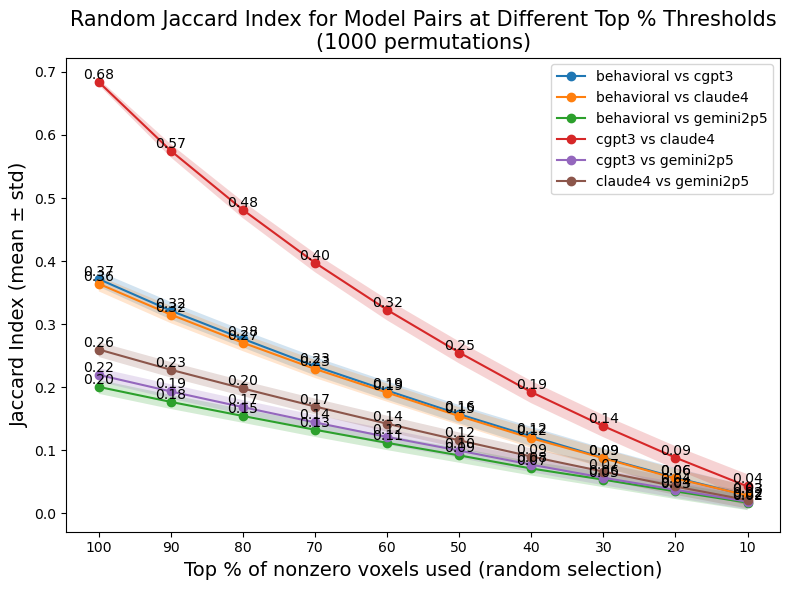

In [73]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import itertools

# Model names and paths
model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz"
}

# Load all t-maps and flatten
flat_maps = {}
nonzero_indices = {}
for name in model_names:
    img = nib.load(tmap_paths[name])
    data = img.get_fdata()
    flat = data.flatten()
    flat_maps[name] = flat
    nonzero_indices[name] = np.where(flat != 0)[0]

# Find the minimum nonzero voxel count across all models
min_nonzero = min([len(nonzero_indices[name]) for name in model_names])

# Define percentages to test (from 70% to 10%)
percentages = np.arange(100, 9, -10)
n_permutations = 1000

# Prepare to store mean and std Jaccard indices for each pair and each percentage
pair_names = []
for i, j in itertools.combinations(range(len(model_names)), 2):
    pair_names.append(f"{model_names[i]} vs {model_names[j]}")
jaccard_means = {pair: [] for pair in pair_names}
jaccard_stds = {pair: [] for pair in pair_names}

rng = np.random.default_rng()

for perc in percentages:
    n_vox = int(min_nonzero * perc / 100)
    # Store Jaccard for all permutations for each pair
    jaccard_perm = {pair: [] for pair in pair_names}
    for perm in range(n_permutations):
        # For each model, randomly select n_vox from its nonzero voxels
        rand_voxel_indices = {}
        for name in model_names:
            idxs = nonzero_indices[name]
            if len(idxs) < n_vox:
                selected = idxs  # fallback if not enough
            else:
                selected = rng.choice(idxs, size=n_vox, replace=False)
            rand_voxel_indices[name] = set(selected)
        # Compute Jaccard for each pair
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = rand_voxel_indices[model_names[i]]
            set2 = rand_voxel_indices[model_names[j]]
            intersection = len(set1 & set2)
            union = len(set1 | set2)
            jaccard = intersection / union if union > 0 else np.nan
            pair = f"{model_names[i]} vs {model_names[j]}"
            jaccard_perm[pair].append(jaccard)
    # Store mean and std for each pair at this percentage
    for pair in pair_names:
        jaccard_means[pair].append(np.nanmean(jaccard_perm[pair]))
        jaccard_stds[pair].append(np.nanstd(jaccard_perm[pair]))

plt.figure(figsize=(8, 6))
for pair in pair_names:
    means = jaccard_means[pair]
    stds = jaccard_stds[pair]
    plt.plot(percentages, means, marker='o', label=pair)
    plt.fill_between(percentages, np.array(means)-np.array(stds), np.array(means)+np.array(stds), alpha=0.2)
    # Annotate each point with its value
    for x, y in zip(percentages, means):
        plt.text(x, y, f"{y:.2f}", fontsize=10, ha='center', va='bottom')

plt.xlabel("Top % of nonzero voxels used (random selection)", fontsize=14)
plt.ylabel("Jaccard Index (mean ± std)", fontsize=14)
plt.title("Random Jaccard Index for Model Pairs at Different Top % Thresholds\n(1000 permutations)", fontsize=15)
plt.xticks(percentages)
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

Loading brain maps...
Minimum nonzero voxels across models: 592
Total brain voxels: 153594

Analyzing 100% threshold (592 voxels)...
  Running permutation null model...
  Running spatial rotation null model...
    behavioral vs cgpt3: Observed=0.684, Perm_null=0.371(z=25.33, p=0.000), Spatial_null=0.628(z=3.95, p=0.010)
    behavioral vs claude4: Observed=0.642, Perm_null=0.364(z=23.10, p=0.000), Spatial_null=0.601(z=3.81, p=0.000)
    behavioral vs gemini2p5: Observed=0.439, Perm_null=0.200(z=21.45, p=0.000), Spatial_null=0.441(z=-0.24, p=0.620)
    cgpt3 vs claude4: Observed=0.709, Perm_null=0.684(z=5.40, p=0.000), Spatial_null=0.699(z=0.91, p=0.260)
    cgpt3 vs gemini2p5: Observed=0.390, Perm_null=0.220(z=16.38, p=0.000), Spatial_null=0.356(z=3.83, p=0.000)
    claude4 vs gemini2p5: Observed=0.487, Perm_null=0.261(z=19.30, p=0.000), Spatial_null=0.460(z=2.59, p=0.010)

Analyzing 90% threshold (532 voxels)...
  Running permutation null model...
  Running spatial rotation null model.

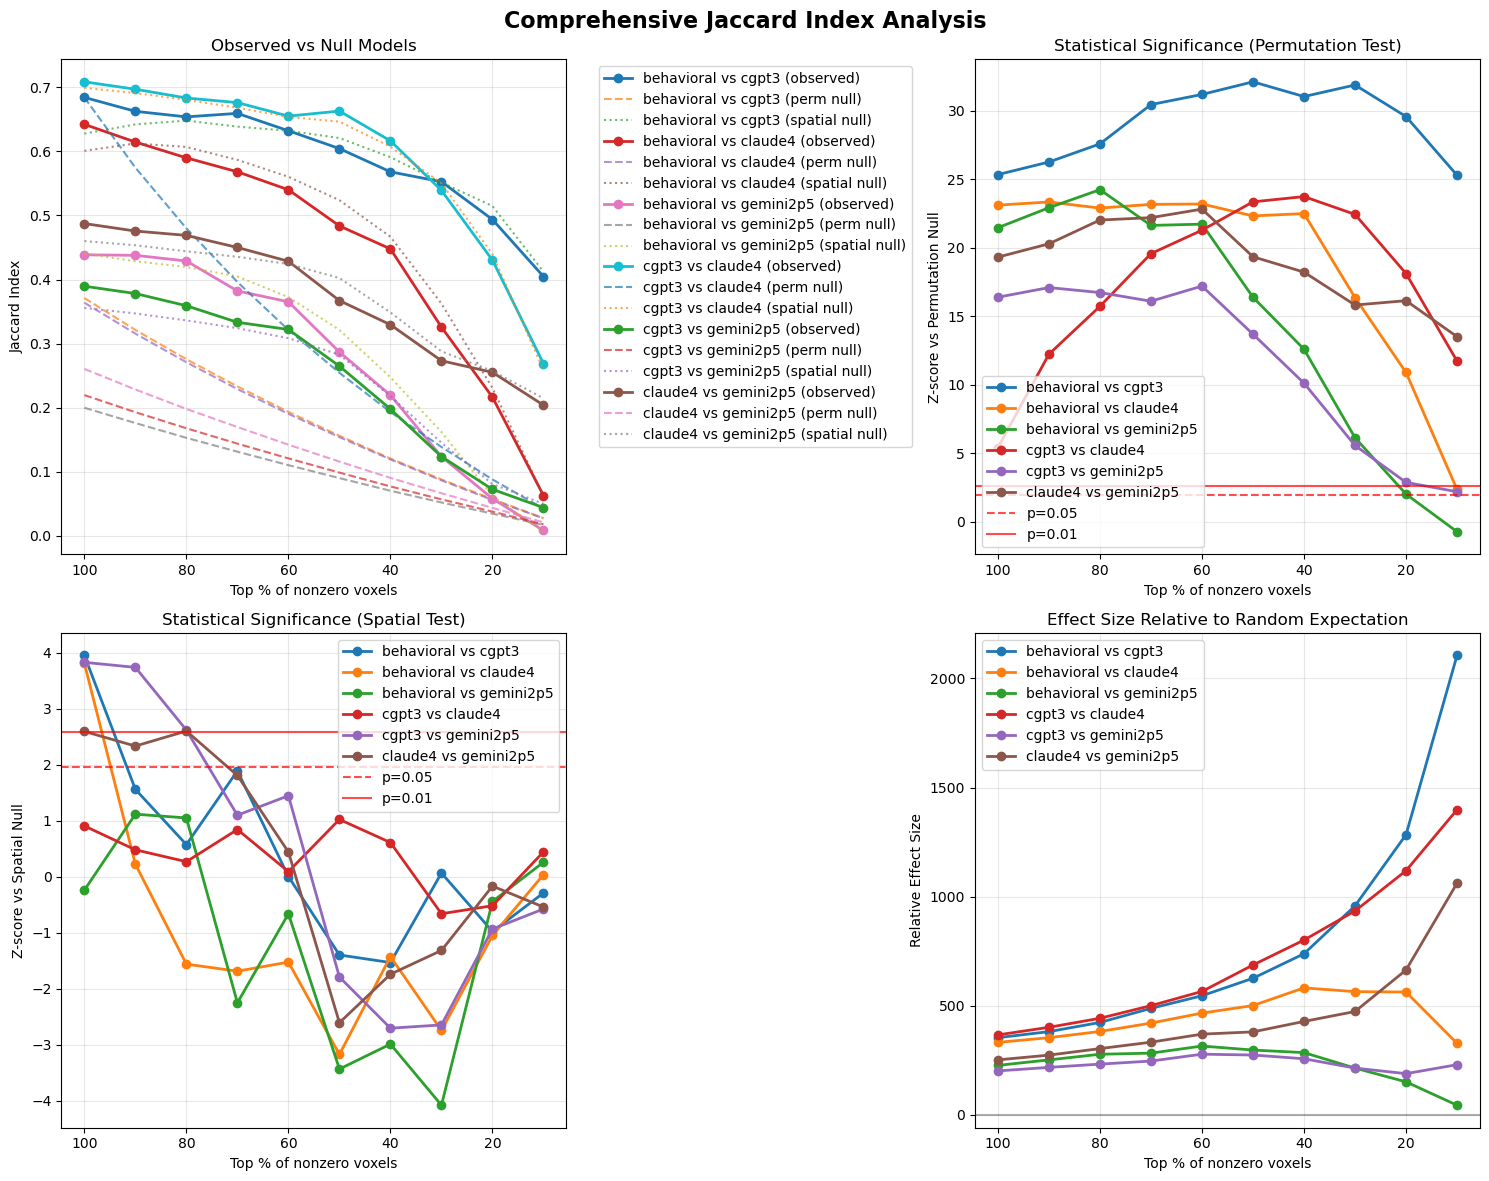


SUMMARY STATISTICS

Top 100% threshold:
----------------------------------------
behavioral vs cgpt3      : JI=0.684, Z_perm= 25.33***, Z_spatial=  3.95*  
behavioral vs claude4    : JI=0.642, Z_perm= 23.10***, Z_spatial=  3.81***
behavioral vs gemini2p5  : JI=0.439, Z_perm= 21.45***, Z_spatial= -0.24   
cgpt3 vs claude4         : JI=0.709, Z_perm=  5.40***, Z_spatial=  0.91   
cgpt3 vs gemini2p5       : JI=0.390, Z_perm= 16.38***, Z_spatial=  3.83***
claude4 vs gemini2p5     : JI=0.487, Z_perm= 19.30***, Z_spatial=  2.59*  

Top 50% threshold:
----------------------------------------
behavioral vs cgpt3      : JI=0.604, Z_perm= 32.10***, Z_spatial= -1.40   
behavioral vs claude4    : JI=0.484, Z_perm= 22.31***, Z_spatial= -3.17   
behavioral vs gemini2p5  : JI=0.287, Z_perm= 16.37***, Z_spatial= -3.43   
cgpt3 vs claude4         : JI=0.663, Z_perm= 23.34***, Z_spatial=  1.02   
cgpt3 vs gemini2p5       : JI=0.265, Z_perm= 13.68***, Z_spatial= -1.79   
claude4 vs gemini2p5     : JI=0.

In [74]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import itertools
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import rotate
import seaborn as sns

# Model names and paths
model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz"
}

def load_brain_maps(model_names, tmap_paths):
    """Load brain maps and return both 3D and flattened versions."""
    brain_maps_3d = {}
    flat_maps = {}
    nonzero_indices = {}
    
    for name in model_names:
        img = nib.load(tmap_paths[name])
        data = img.get_fdata()
        flat = data.flatten()
        
        brain_maps_3d[name] = data
        flat_maps[name] = flat
        nonzero_indices[name] = np.where(flat != 0)[0]
    
    return brain_maps_3d, flat_maps, nonzero_indices

def calculate_jaccard(set1, set2):
    """Calculate Jaccard Index between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

def get_top_voxels(flat_map, nonzero_indices, n_voxels):
    """Get top n voxels based on absolute values."""
    nonzero_vals = flat_map[nonzero_indices]
    # Use absolute values to rank voxels
    abs_vals = np.abs(nonzero_vals)
    top_idx = np.argsort(abs_vals)[::-1][:n_voxels]
    return set(nonzero_indices[top_idx])

def permutation_null_model(flat_maps, nonzero_indices, model_names, n_voxels, n_permutations=1000):
    """
    Create null distribution by permuting voxel values within each map's nonzero region.
    This preserves the number of nonzero voxels but destroys spatial structure.
    """
    rng = np.random.default_rng(42)  # For reproducibility
    
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    null_jaccards = {pair: [] for pair in pair_names}
    
    for _ in range(n_permutations):
        # Create permuted maps
        permuted_maps = {}
        for name in model_names:
            flat_copy = flat_maps[name].copy()
            nonzero_idx = nonzero_indices[name]
            nonzero_vals = flat_copy[nonzero_idx]
            # Permute only the nonzero values
            permuted_vals = rng.permutation(nonzero_vals)
            flat_copy[nonzero_idx] = permuted_vals
            permuted_maps[name] = flat_copy
        
        # Get top voxels from permuted maps
        top_voxels_perm = {}
        for name in model_names:
            top_voxels_perm[name] = get_top_voxels(
                permuted_maps[name], nonzero_indices[name], n_voxels
            )
        
        # Calculate Jaccard for each pair
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = top_voxels_perm[model_names[i]]
            set2 = top_voxels_perm[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            null_jaccards[pair].append(jaccard)
    
    return null_jaccards

def spatial_rotation_null(brain_maps_3d, flat_maps, nonzero_indices, model_names, 
                         n_voxels, n_rotations=100):
    """
    Create spatial null by rotating one brain map relative to another.
    This preserves spatial structure but destroys spatial correspondence.
    """
    rng = np.random.default_rng(42)
    
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    spatial_null_jaccards = {pair: [] for pair in pair_names}
    
    # Generate random rotation angles
    angles = rng.uniform(10, 350, n_rotations)  # Avoid 0 and 360 degrees
    
    for angle in angles:
        rotated_maps = {}
        rotated_flat_maps = {}
        rotated_nonzero_indices = {}
        
        # Rotate each brain map
        for name in model_names:
            rotated_3d = rotate(brain_maps_3d[name], angle, axes=(0, 1), 
                              reshape=False, order=1, mode='constant', cval=0)
            rotated_flat = rotated_3d.flatten()
            rotated_nonzero_idx = np.where(rotated_flat != 0)[0]
            
            rotated_maps[name] = rotated_3d
            rotated_flat_maps[name] = rotated_flat
            rotated_nonzero_indices[name] = rotated_nonzero_idx
        
        # Get top voxels from rotated maps
        top_voxels_rot = {}
        for name in model_names:
            if len(rotated_nonzero_indices[name]) >= n_voxels:
                top_voxels_rot[name] = get_top_voxels(
                    rotated_flat_maps[name], rotated_nonzero_indices[name], n_voxels
                )
            else:
                # If rotation reduced nonzero voxels, use all available
                top_voxels_rot[name] = set(rotated_nonzero_indices[name])
        
        # Calculate Jaccard for each pair
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = top_voxels_rot[model_names[i]]
            set2 = top_voxels_rot[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            spatial_null_jaccards[pair].append(jaccard)
    
    return spatial_null_jaccards

def hypergeometric_expected_jaccard(n_voxels_1, n_voxels_2, total_voxels):
    """
    Calculate expected Jaccard Index under hypergeometric distribution.
    This assumes random placement of activation within the brain volume.
    """
    # Expected intersection size
    expected_intersection = (n_voxels_1 * n_voxels_2) / total_voxels
    
    # Expected union size
    expected_union = n_voxels_1 + n_voxels_2 - expected_intersection
    
    # Expected Jaccard
    expected_jaccard = expected_intersection / expected_union if expected_union > 0 else 0
    
    return expected_jaccard

def calculate_statistical_significance(observed_jaccard, null_distribution):
    """Calculate p-value and z-score for observed Jaccard against null."""
    null_mean = np.mean(null_distribution)
    null_std = np.std(null_distribution)
    
    # Z-score
    z_score = (observed_jaccard - null_mean) / null_std if null_std > 0 else 0
    
    # P-value (two-tailed)
    p_value = len([x for x in null_distribution if x >= observed_jaccard]) / len(null_distribution)
    
    return z_score, p_value, null_mean, null_std

def main():
    # Load data
    print("Loading brain maps...")
    brain_maps_3d, flat_maps, nonzero_indices = load_brain_maps(model_names, tmap_paths)
    
    # Find minimum nonzero voxel count
    min_nonzero = min([len(nonzero_indices[name]) for name in model_names])
    total_voxels = len(flat_maps[model_names[0]])
    
    print(f"Minimum nonzero voxels across models: {min_nonzero}")
    print(f"Total brain voxels: {total_voxels}")
    
    # Define percentages to test
    percentages = np.arange(100, 9, -10)
    
    # Prepare results storage
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    results = {
        'observed': {pair: [] for pair in pair_names},
        'permutation_null': {pair: [] for pair in pair_names},
        'spatial_null': {pair: [] for pair in pair_names},
        'hypergeometric': {pair: [] for pair in pair_names},
        'z_scores_perm': {pair: [] for pair in pair_names},
        'p_values_perm': {pair: [] for pair in pair_names},
        'z_scores_spatial': {pair: [] for pair in pair_names},
        'p_values_spatial': {pair: [] for pair in pair_names}
    }
    
    # Main analysis loop
    for perc in percentages:
        n_vox = int(min_nonzero * perc / 100)
        print(f"\nAnalyzing {perc}% threshold ({n_vox} voxels)...")
        
        # Calculate observed Jaccard indices
        observed_top_voxels = {}
        for name in model_names:
            observed_top_voxels[name] = get_top_voxels(
                flat_maps[name], nonzero_indices[name], n_vox
            )
        
        observed_jaccards = {}
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = observed_top_voxels[model_names[i]]
            set2 = observed_top_voxels[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            observed_jaccards[pair] = jaccard
            results['observed'][pair].append(jaccard)
        
        # Hypergeometric expectation
        hyper_expected = hypergeometric_expected_jaccard(n_vox, n_vox, total_voxels)
        for pair in pair_names:
            results['hypergeometric'][pair].append(hyper_expected)
        
        # Permutation null model
        print("  Running permutation null model...")
        perm_null = permutation_null_model(
            flat_maps, nonzero_indices, model_names, n_vox, n_permutations=1000
        )
        
        # Spatial rotation null model
        print("  Running spatial rotation null model...")
        spatial_null = spatial_rotation_null(
            brain_maps_3d, flat_maps, nonzero_indices, model_names, n_vox, n_rotations=100
        )
        
        # Calculate statistics for each pair
        for pair in pair_names:
            obs_ji = observed_jaccards[pair]
            
            # Permutation null statistics
            perm_null_ji = perm_null[pair]
            z_perm, p_perm, mean_perm, std_perm = calculate_statistical_significance(
                obs_ji, perm_null_ji
            )
            
            results['permutation_null'][pair].append(mean_perm)
            results['z_scores_perm'][pair].append(z_perm)
            results['p_values_perm'][pair].append(p_perm)
            
            # Spatial null statistics
            spatial_null_ji = spatial_null[pair]
            z_spatial, p_spatial, mean_spatial, std_spatial = calculate_statistical_significance(
                obs_ji, spatial_null_ji
            )
            
            results['spatial_null'][pair].append(mean_spatial)
            results['z_scores_spatial'][pair].append(z_spatial)
            results['p_values_spatial'][pair].append(p_spatial)
            
            print(f"    {pair}: Observed={obs_ji:.3f}, "
                  f"Perm_null={mean_perm:.3f}(z={z_perm:.2f}, p={p_perm:.3f}), "
                  f"Spatial_null={mean_spatial:.3f}(z={z_spatial:.2f}, p={p_spatial:.3f})")
    
    # Create comprehensive visualization
    create_comprehensive_plots(results, percentages, pair_names)
    
    return results

def create_comprehensive_plots(results, percentages, pair_names):
    """Create comprehensive visualization of results."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Comprehensive Jaccard Index Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Observed vs Null Models
    ax1 = axes[0, 0]
    for pair in pair_names:
        ax1.plot(percentages, results['observed'][pair], 'o-', linewidth=2, 
                label=f'{pair} (observed)', markersize=6)
        ax1.plot(percentages, results['permutation_null'][pair], '--', alpha=0.7,
                label=f'{pair} (perm null)')
        ax1.plot(percentages, results['spatial_null'][pair], ':', alpha=0.7,
                label=f'{pair} (spatial null)')
    
    ax1.set_xlabel('Top % of nonzero voxels')
    ax1.set_ylabel('Jaccard Index')
    ax1.set_title('Observed vs Null Models')
    ax1.invert_xaxis()
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Z-scores for Permutation Null
    ax2 = axes[0, 1]
    for pair in pair_names:
        z_scores = results['z_scores_perm'][pair]
        ax2.plot(percentages, z_scores, 'o-', linewidth=2, label=pair, markersize=6)
    
    ax2.axhline(y=1.96, color='red', linestyle='--', alpha=0.7, label='p=0.05')
    ax2.axhline(y=2.58, color='red', linestyle='-', alpha=0.7, label='p=0.01')
    ax2.set_xlabel('Top % of nonzero voxels')
    ax2.set_ylabel('Z-score vs Permutation Null')
    ax2.set_title('Statistical Significance (Permutation Test)')
    ax2.invert_xaxis()
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Z-scores for Spatial Null
    ax3 = axes[1, 0]
    for pair in pair_names:
        z_scores = results['z_scores_spatial'][pair]
        ax3.plot(percentages, z_scores, 'o-', linewidth=2, label=pair, markersize=6)
    
    ax3.axhline(y=1.96, color='red', linestyle='--', alpha=0.7, label='p=0.05')
    ax3.axhline(y=2.58, color='red', linestyle='-', alpha=0.7, label='p=0.01')
    ax3.set_xlabel('Top % of nonzero voxels')
    ax3.set_ylabel('Z-score vs Spatial Null')
    ax3.set_title('Statistical Significance (Spatial Test)')
    ax3.invert_xaxis()
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Effect size comparison
    ax4 = axes[1, 1]
    for pair in pair_names:
        observed = np.array(results['observed'][pair])
        hyper_expected = np.array(results['hypergeometric'][pair])
        effect_size = (observed - hyper_expected) / hyper_expected
        ax4.plot(percentages, effect_size, 'o-', linewidth=2, label=pair, markersize=6)
    
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax4.set_xlabel('Top % of nonzero voxels')
    ax4.set_ylabel('Relative Effect Size')
    ax4.set_title('Effect Size Relative to Random Expectation')
    ax4.invert_xaxis()
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create summary statistics table
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    
    for i, perc in enumerate([100, 50, 20]):  # Show key percentages
        if perc in percentages:
            idx = list(percentages).index(perc)
            print(f"\nTop {perc}% threshold:")
            print("-" * 40)
            for pair in pair_names:
                obs = results['observed'][pair][idx]
                z_perm = results['z_scores_perm'][pair][idx]
                p_perm = results['p_values_perm'][pair][idx]
                z_spatial = results['z_scores_spatial'][pair][idx]
                p_spatial = results['p_values_spatial'][pair][idx]
                
                sig_perm = "***" if p_perm < 0.001 else "**" if p_perm < 0.01 else "*" if p_perm < 0.05 else ""
                sig_spatial = "***" if p_spatial < 0.001 else "**" if p_spatial < 0.01 else "*" if p_spatial < 0.05 else ""
                
                print(f"{pair:25}: JI={obs:.3f}, "
                      f"Z_perm={z_perm:6.2f}{sig_perm:3}, "
                      f"Z_spatial={z_spatial:6.2f}{sig_spatial:3}")

if __name__ == "__main__":
    results = main()

Loading brain maps...
Minimum nonzero voxels across models: 592
Total brain voxels: 153594

Analyzing 100% threshold (592 voxels)...
  Running permutation null model...
    behavioral vs cgpt3: Observed=0.684, Perm_null=0.371(z=25.33, p=0.000)
    behavioral vs claude4: Observed=0.642, Perm_null=0.364(z=23.10, p=0.000)
    behavioral vs gemini2p5: Observed=0.439, Perm_null=0.200(z=21.45, p=0.000)
    cgpt3 vs claude4: Observed=0.709, Perm_null=0.684(z=5.40, p=0.000)
    cgpt3 vs gemini2p5: Observed=0.390, Perm_null=0.220(z=16.38, p=0.000)
    claude4 vs gemini2p5: Observed=0.487, Perm_null=0.261(z=19.30, p=0.000)

Analyzing 90% threshold (532 voxels)...
  Running permutation null model...
    behavioral vs cgpt3: Observed=0.662, Perm_null=0.321(z=26.25, p=0.000)
    behavioral vs claude4: Observed=0.615, Perm_null=0.316(z=23.33, p=0.000)
    behavioral vs gemini2p5: Observed=0.438, Perm_null=0.176(z=22.91, p=0.000)
    cgpt3 vs claude4: Observed=0.697, Perm_null=0.575(z=12.22, p=0.000)

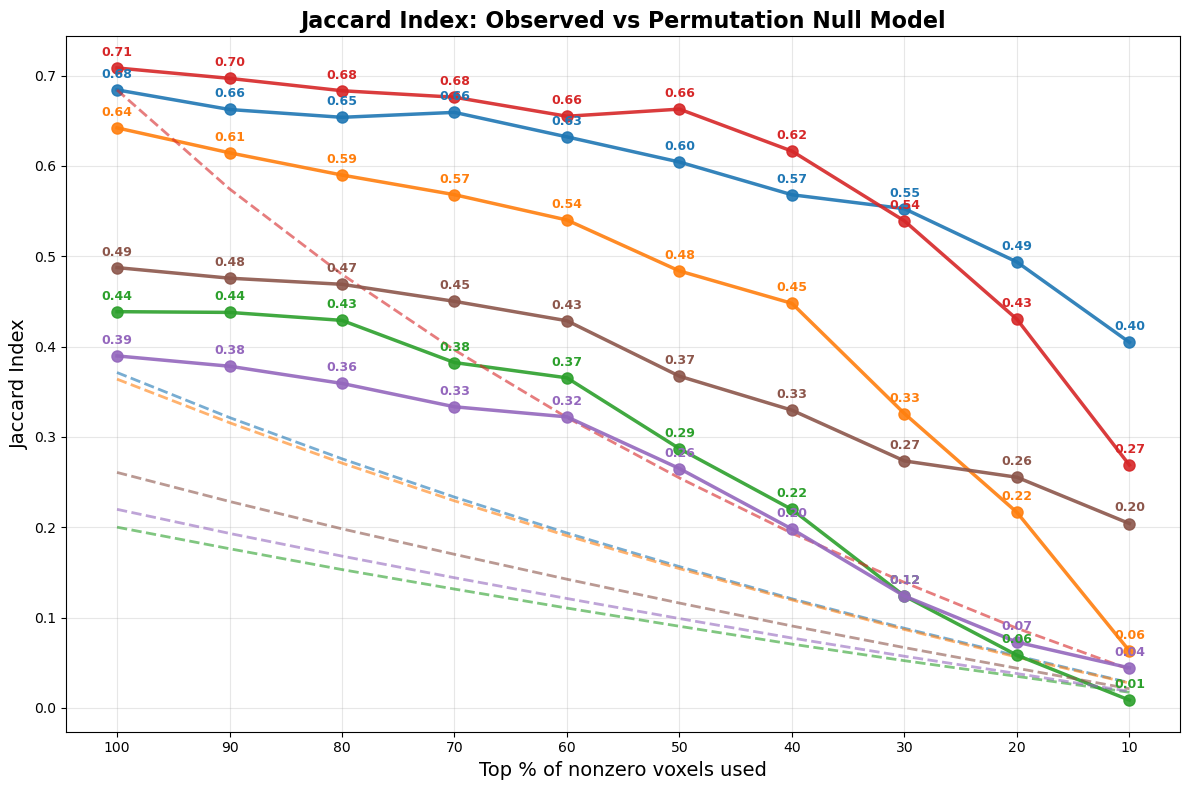


JACCARD INDEX SUMMARY WITH STATISTICAL SIGNIFICANCE
Pair                      %    Observed   Perm_Null  Z-score  P-value  Significance
----------------------------------------------------------------------------------------------------

behavioral vs cgpt3       100  0.684      0.371      25.33    0.000    ***
behavioral vs claude4     100  0.642      0.364      23.10    0.000    ***
behavioral vs gemini2p5   100  0.439      0.200      21.45    0.000    ***
cgpt3 vs claude4          100  0.709      0.684      5.40     0.000    ***
cgpt3 vs gemini2p5        100  0.390      0.220      16.38    0.000    ***
claude4 vs gemini2p5      100  0.487      0.261      19.30    0.000    ***
----------------------------------------------------------------------------------------------------
behavioral vs cgpt3       90   0.662      0.321      26.25    0.000    ***
behavioral vs claude4     90   0.615      0.316      23.33    0.000    ***
behavioral vs gemini2p5   90   0.438      0.176      22.91  

In [75]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import itertools
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

# Model names and paths
model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz"
}

def load_brain_maps(model_names, tmap_paths):
    """Load brain maps and return both 3D and flattened versions."""
    brain_maps_3d = {}
    flat_maps = {}
    nonzero_indices = {}
    
    for name in model_names:
        img = nib.load(tmap_paths[name])
        data = img.get_fdata()
        flat = data.flatten()
        
        brain_maps_3d[name] = data
        flat_maps[name] = flat
        nonzero_indices[name] = np.where(flat != 0)[0]
    
    return brain_maps_3d, flat_maps, nonzero_indices

def calculate_jaccard(set1, set2):
    """Calculate Jaccard Index between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

def get_top_voxels(flat_map, nonzero_indices, n_voxels):
    """Get top n voxels based on absolute values."""
    nonzero_vals = flat_map[nonzero_indices]
    # Use absolute values to rank voxels
    abs_vals = np.abs(nonzero_vals)
    top_idx = np.argsort(abs_vals)[::-1][:n_voxels]
    return set(nonzero_indices[top_idx])

def permutation_null_model(flat_maps, nonzero_indices, model_names, n_voxels, n_permutations=1000):
    """
    Create null distribution by permuting voxel values within each map's nonzero region.
    This preserves the number of nonzero voxels but destroys spatial structure.
    """
    rng = np.random.default_rng(42)  # For reproducibility
    
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    null_jaccards = {pair: [] for pair in pair_names}
    
    for _ in range(n_permutations):
        # Create permuted maps
        permuted_maps = {}
        for name in model_names:
            flat_copy = flat_maps[name].copy()
            nonzero_idx = nonzero_indices[name]
            nonzero_vals = flat_copy[nonzero_idx]
            # Permute only the nonzero values
            permuted_vals = rng.permutation(nonzero_vals)
            flat_copy[nonzero_idx] = permuted_vals
            permuted_maps[name] = flat_copy
        
        # Get top voxels from permuted maps
        top_voxels_perm = {}
        for name in model_names:
            top_voxels_perm[name] = get_top_voxels(
                permuted_maps[name], nonzero_indices[name], n_voxels
            )
        
        # Calculate Jaccard for each pair
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = top_voxels_perm[model_names[i]]
            set2 = top_voxels_perm[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            null_jaccards[pair].append(jaccard)
    
    return null_jaccards



def hypergeometric_expected_jaccard(n_voxels_1, n_voxels_2, total_voxels):
    """
    Calculate expected Jaccard Index under hypergeometric distribution.
    This assumes random placement of activation within the brain volume.
    """
    # Expected intersection size
    expected_intersection = (n_voxels_1 * n_voxels_2) / total_voxels
    
    # Expected union size
    expected_union = n_voxels_1 + n_voxels_2 - expected_intersection
    
    # Expected Jaccard
    expected_jaccard = expected_intersection / expected_union if expected_union > 0 else 0
    
    return expected_jaccard

def calculate_statistical_significance(observed_jaccard, null_distribution):
    """Calculate p-value and z-score for observed Jaccard against null."""
    null_mean = np.mean(null_distribution)
    null_std = np.std(null_distribution)
    
    # Z-score
    z_score = (observed_jaccard - null_mean) / null_std if null_std > 0 else 0
    
    # P-value (two-tailed)
    p_value = len([x for x in null_distribution if x >= observed_jaccard]) / len(null_distribution)
    
    return z_score, p_value, null_mean, null_std

def main():
    # Load data
    print("Loading brain maps...")
    brain_maps_3d, flat_maps, nonzero_indices = load_brain_maps(model_names, tmap_paths)
    
    # Find minimum nonzero voxel count
    min_nonzero = min([len(nonzero_indices[name]) for name in model_names])
    total_voxels = len(flat_maps[model_names[0]])
    
    print(f"Minimum nonzero voxels across models: {min_nonzero}")
    print(f"Total brain voxels: {total_voxels}")
    
    # Define percentages to test
    percentages = np.arange(100, 9, -10)
    
    # Prepare results storage
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    results = {
        'observed': {pair: [] for pair in pair_names},
        'permutation_null': {pair: [] for pair in pair_names},
        'hypergeometric': {pair: [] for pair in pair_names},
        'z_scores_perm': {pair: [] for pair in pair_names},
        'p_values_perm': {pair: [] for pair in pair_names}
    }
    
    # Main analysis loop
    for perc in percentages:
        n_vox = int(min_nonzero * perc / 100)
        print(f"\nAnalyzing {perc}% threshold ({n_vox} voxels)...")
        
        # Calculate observed Jaccard indices
        observed_top_voxels = {}
        for name in model_names:
            observed_top_voxels[name] = get_top_voxels(
                flat_maps[name], nonzero_indices[name], n_vox
            )
        
        observed_jaccards = {}
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = observed_top_voxels[model_names[i]]
            set2 = observed_top_voxels[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            observed_jaccards[pair] = jaccard
            results['observed'][pair].append(jaccard)
        
        # Hypergeometric expectation
        hyper_expected = hypergeometric_expected_jaccard(n_vox, n_vox, total_voxels)
        for pair in pair_names:
            results['hypergeometric'][pair].append(hyper_expected)
        
        # Permutation null model
        print("  Running permutation null model...")
        perm_null = permutation_null_model(
            flat_maps, nonzero_indices, model_names, n_vox, n_permutations=1000
        )
        
        # Calculate statistics for each pair
        for pair in pair_names:
            obs_ji = observed_jaccards[pair]
            
            # Permutation null statistics
            perm_null_ji = perm_null[pair]
            z_perm, p_perm, mean_perm, std_perm = calculate_statistical_significance(
                obs_ji, perm_null_ji
            )
            
            results['permutation_null'][pair].append(mean_perm)
            results['z_scores_perm'][pair].append(z_perm)
            results['p_values_perm'][pair].append(p_perm)
            
            print(f"    {pair}: Observed={obs_ji:.3f}, "
                  f"Perm_null={mean_perm:.3f}(z={z_perm:.2f}, p={p_perm:.3f})")
    
    # Create single plot
    create_single_plot(results, percentages, pair_names)
    
    return results

def create_single_plot(results, percentages, pair_names):
    """Create single plot with color-coded model pairs and value annotations."""
    
    # Define colors for each pair - same color family for related comparisons
    colors = {
        'behavioral vs cgpt3': '#1f77b4',      # Blue
        'behavioral vs claude4': '#ff7f0e',    # Orange  
        'behavioral vs gemini2p5': '#2ca02c',  # Green
        'cgpt3 vs claude4': '#d62728',         # Red
        'cgpt3 vs gemini2p5': '#9467bd',       # Purple
        'claude4 vs gemini2p5': '#8c564b'      # Brown
    }
    
    plt.figure(figsize=(12, 8))
    
    for pair in pair_names:
        color = colors.get(pair, 'black')  # Default to black if pair not found
        
        # Plot observed values with solid line
        observed_values = results['observed'][pair]
        plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, 
                markersize=8, label=f'{pair} (observed)', alpha=0.9)
        
        # Plot permutation null with dashed line (same color, lighter)
        perm_null_values = results['permutation_null'][pair]
        plt.plot(percentages, perm_null_values, '--', color=color, linewidth=2, 
                alpha=0.6, label=f'{pair} (perm null)')
        
        # Annotate observed values
        for x, y in zip(percentages, observed_values):
            plt.text(x, y + 0.01, f'{y:.2f}', fontsize=9, ha='center', va='bottom',
                    color=color, fontweight='bold')
    
    plt.xlabel('Top % of nonzero voxels used', fontsize=14)
    plt.ylabel('Jaccard Index', fontsize=14)
    plt.title('Jaccard Index: Observed vs Permutation Null Model', fontsize=16, fontweight='bold')
    plt.xticks(percentages)
    plt.gca().invert_xaxis()
    
    # Create custom legend - group by observed vs null
    observed_handles = []
    null_handles = []
    
    for pair in pair_names:
        color = colors.get(pair, 'black')
        # Create legend entries
        observed_handles.append(plt.Line2D([0], [0], color=color, linewidth=2.5, 
                                         linestyle='-', marker='o', markersize=6, 
                                         label=f'{pair}'))
        null_handles.append(plt.Line2D([0], [0], color=color, linewidth=2, 
                                     linestyle='--', alpha=0.6, 
                                     label=f'{pair} (null)'))
    
    # Create two-column legend
    legend1 = plt.legend(handles=observed_handles, title='Observed', 
                        loc='upper left', bbox_to_anchor=(1.02, 1))
    legend2 = plt.legend(handles=null_handles, title='Permutation Null', 
                        loc='upper left', bbox_to_anchor=(1.02, 0.6))
    
    # Add both legends to plot
    plt.gca().add_artist(legend1)
    plt.gca().add_artist(legend2)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n" + "="*100)
    print("JACCARD INDEX SUMMARY WITH STATISTICAL SIGNIFICANCE")
    print("="*100)
    print(f"{'Pair':<25} {'%':<4} {'Observed':<10} {'Perm_Null':<10} {'Z-score':<8} {'P-value':<8} {'Significance'}")
    print("-" * 100)
    
    for i, perc in enumerate(percentages):
        if i == 0:  # Add separator for first percentage
            print()
        for pair in pair_names:
            obs = results['observed'][pair][i]
            perm_null = results['permutation_null'][pair][i]
            z_score = results['z_scores_perm'][pair][i]
            p_value = results['p_values_perm'][pair][i]
            
            # Significance stars
            if p_value < 0.001:
                sig = "***"
            elif p_value < 0.01:
                sig = "**"
            elif p_value < 0.05:
                sig = "*"
            else:
                sig = "ns"
            
            print(f"{pair:<25} {perc:<4} {obs:<10.3f} {perm_null:<10.3f} "
                  f"{z_score:<8.2f} {p_value:<8.3f} {sig}")
        
        if i < len(percentages) - 1:  # Add separator between percentages
            print("-" * 100)

if __name__ == "__main__":
    results = main()

Loading brain maps...
Minimum nonzero voxels across models: 592
Total brain voxels: 153594

Analyzing 100% threshold (592 voxels)...
  Running permutation null model...
    behavioral vs cgpt3: Observed=0.684, Perm_null=0.371(z=25.33, p=0.000)
    behavioral vs claude4: Observed=0.642, Perm_null=0.364(z=23.10, p=0.000)
    behavioral vs gemini2p5: Observed=0.439, Perm_null=0.200(z=21.45, p=0.000)
    cgpt3 vs claude4: Observed=0.709, Perm_null=0.684(z=5.40, p=0.000)
    cgpt3 vs gemini2p5: Observed=0.390, Perm_null=0.220(z=16.38, p=0.000)
    claude4 vs gemini2p5: Observed=0.487, Perm_null=0.261(z=19.30, p=0.000)

Analyzing 90% threshold (532 voxels)...
  Running permutation null model...
    behavioral vs cgpt3: Observed=0.662, Perm_null=0.321(z=26.25, p=0.000)
    behavioral vs claude4: Observed=0.615, Perm_null=0.316(z=23.33, p=0.000)
    behavioral vs gemini2p5: Observed=0.438, Perm_null=0.176(z=22.91, p=0.000)
    cgpt3 vs claude4: Observed=0.697, Perm_null=0.575(z=12.22, p=0.000)

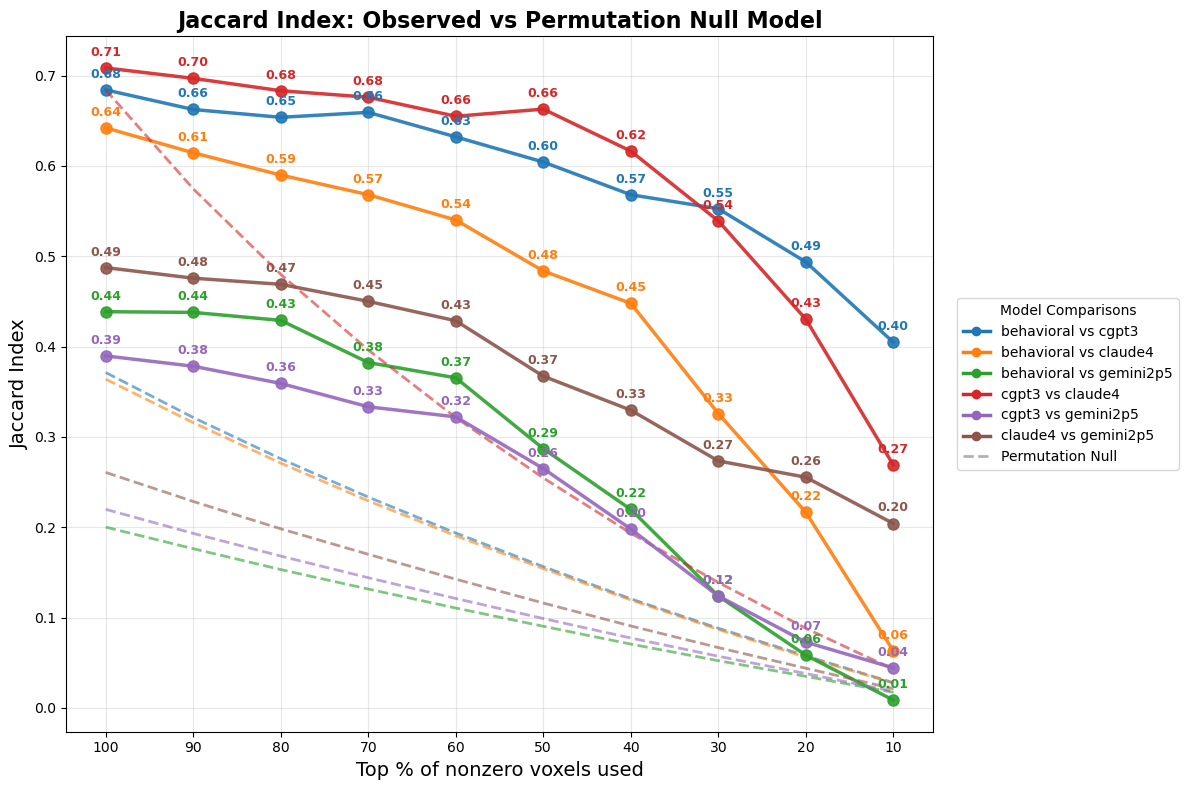


JACCARD INDEX SUMMARY WITH STATISTICAL SIGNIFICANCE
Pair                      %    Observed   Perm_Null  Z-score  P-value  Significance
----------------------------------------------------------------------------------------------------

behavioral vs cgpt3       100  0.684      0.371      25.33    0.000    ***
behavioral vs claude4     100  0.642      0.364      23.10    0.000    ***
behavioral vs gemini2p5   100  0.439      0.200      21.45    0.000    ***
cgpt3 vs claude4          100  0.709      0.684      5.40     0.000    ***
cgpt3 vs gemini2p5        100  0.390      0.220      16.38    0.000    ***
claude4 vs gemini2p5      100  0.487      0.261      19.30    0.000    ***
----------------------------------------------------------------------------------------------------
behavioral vs cgpt3       90   0.662      0.321      26.25    0.000    ***
behavioral vs claude4     90   0.615      0.316      23.33    0.000    ***
behavioral vs gemini2p5   90   0.438      0.176      22.91  

In [76]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import itertools
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import pickle
import os
from datetime import datetime

# Model names and paths
model_names = ["behavioral", "cgpt3", "claude4", "gemini2p5"]
tmap_paths = {
    "behavioral": "./outputs/tBrainmap/tmap_beh60_p05_v2.nii.gz",
    "cgpt3": "./outputs/tBrainmap/tmap_cgpt3_p01_fisherz.nii.gz",
    "claude4": "./outputs/tBrainmap/tmap_claude4_p01_fisherz.nii.gz",
    "gemini2p5": "./outputs/tBrainmap/tmap_gemini2p5_p01_fisherz.nii.gz"
}

def load_brain_maps(model_names, tmap_paths):
    """Load brain maps and return both 3D and flattened versions."""
    brain_maps_3d = {}
    flat_maps = {}
    nonzero_indices = {}
    
    for name in model_names:
        img = nib.load(tmap_paths[name])
        data = img.get_fdata()
        flat = data.flatten()
        
        brain_maps_3d[name] = data
        flat_maps[name] = flat
        nonzero_indices[name] = np.where(flat != 0)[0]
    
    return brain_maps_3d, flat_maps, nonzero_indices

def calculate_jaccard(set1, set2):
    """Calculate Jaccard Index between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

def get_top_voxels(flat_map, nonzero_indices, n_voxels):
    """Get top n voxels based on absolute values."""
    nonzero_vals = flat_map[nonzero_indices]
    # Use absolute values to rank voxels
    abs_vals = np.abs(nonzero_vals)
    top_idx = np.argsort(abs_vals)[::-1][:n_voxels]
    return set(nonzero_indices[top_idx])

def permutation_null_model(flat_maps, nonzero_indices, model_names, n_voxels, n_permutations=1000):
    """
    Create null distribution by permuting voxel values within each map's nonzero region.
    This preserves the number of nonzero voxels but destroys spatial structure.
    """
    rng = np.random.default_rng(42)  # For reproducibility
    
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    null_jaccards = {pair: [] for pair in pair_names}
    
    for _ in range(n_permutations):
        # Create permuted maps
        permuted_maps = {}
        for name in model_names:
            flat_copy = flat_maps[name].copy()
            nonzero_idx = nonzero_indices[name]
            nonzero_vals = flat_copy[nonzero_idx]
            # Permute only the nonzero values
            permuted_vals = rng.permutation(nonzero_vals)
            flat_copy[nonzero_idx] = permuted_vals
            permuted_maps[name] = flat_copy
        
        # Get top voxels from permuted maps
        top_voxels_perm = {}
        for name in model_names:
            top_voxels_perm[name] = get_top_voxels(
                permuted_maps[name], nonzero_indices[name], n_voxels
            )
        
        # Calculate Jaccard for each pair
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = top_voxels_perm[model_names[i]]
            set2 = top_voxels_perm[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            null_jaccards[pair].append(jaccard)
    
    return null_jaccards



def hypergeometric_expected_jaccard(n_voxels_1, n_voxels_2, total_voxels):
    """
    Calculate expected Jaccard Index under hypergeometric distribution.
    This assumes random placement of activation within the brain volume.
    """
    # Expected intersection size
    expected_intersection = (n_voxels_1 * n_voxels_2) / total_voxels
    
    # Expected union size
    expected_union = n_voxels_1 + n_voxels_2 - expected_intersection
    
    # Expected Jaccard
    expected_jaccard = expected_intersection / expected_union if expected_union > 0 else 0
    
    return expected_jaccard

def calculate_statistical_significance(observed_jaccard, null_distribution):
    """Calculate p-value and z-score for observed Jaccard against null."""
    null_mean = np.mean(null_distribution)
    null_std = np.std(null_distribution)
    
    # Z-score
    z_score = (observed_jaccard - null_mean) / null_std if null_std > 0 else 0
    
    # P-value (two-tailed)
    p_value = len([x for x in null_distribution if x >= observed_jaccard]) / len(null_distribution)
    
    return z_score, p_value, null_mean, null_std

def main():
    # Load data
    print("Loading brain maps...")
    brain_maps_3d, flat_maps, nonzero_indices = load_brain_maps(model_names, tmap_paths)
    
    # Find minimum nonzero voxel count
    min_nonzero = min([len(nonzero_indices[name]) for name in model_names])
    total_voxels = len(flat_maps[model_names[0]])
    
    print(f"Minimum nonzero voxels across models: {min_nonzero}")
    print(f"Total brain voxels: {total_voxels}")
    
    # Define percentages to test
    percentages = np.arange(100, 9, -10)
    
    # Prepare results storage
    pair_names = []
    for i, j in itertools.combinations(range(len(model_names)), 2):
        pair_names.append(f"{model_names[i]} vs {model_names[j]}")
    
    results = {
        'observed': {pair: [] for pair in pair_names},
        'permutation_null': {pair: [] for pair in pair_names},
        'hypergeometric': {pair: [] for pair in pair_names},
        'z_scores_perm': {pair: [] for pair in pair_names},
        'p_values_perm': {pair: [] for pair in pair_names}
    }
    
    # Main analysis loop
    for perc in percentages:
        n_vox = int(min_nonzero * perc / 100)
        print(f"\nAnalyzing {perc}% threshold ({n_vox} voxels)...")
        
        # Calculate observed Jaccard indices
        observed_top_voxels = {}
        for name in model_names:
            observed_top_voxels[name] = get_top_voxels(
                flat_maps[name], nonzero_indices[name], n_vox
            )
        
        observed_jaccards = {}
        for i, j in itertools.combinations(range(len(model_names)), 2):
            set1 = observed_top_voxels[model_names[i]]
            set2 = observed_top_voxels[model_names[j]]
            jaccard = calculate_jaccard(set1, set2)
            pair = f"{model_names[i]} vs {model_names[j]}"
            observed_jaccards[pair] = jaccard
            results['observed'][pair].append(jaccard)
        
        # Hypergeometric expectation
        hyper_expected = hypergeometric_expected_jaccard(n_vox, n_vox, total_voxels)
        for pair in pair_names:
            results['hypergeometric'][pair].append(hyper_expected)
        
        # Permutation null model
        print("  Running permutation null model...")
        perm_null = permutation_null_model(
            flat_maps, nonzero_indices, model_names, n_vox, n_permutations=1000
        )
        
        # Calculate statistics for each pair
        for pair in pair_names:
            obs_ji = observed_jaccards[pair]
            
            # Permutation null statistics
            perm_null_ji = perm_null[pair]
            z_perm, p_perm, mean_perm, std_perm = calculate_statistical_significance(
                obs_ji, perm_null_ji
            )
            
            results['permutation_null'][pair].append(mean_perm)
            results['z_scores_perm'][pair].append(z_perm)
            results['p_values_perm'][pair].append(p_perm)
            
            print(f"    {pair}: Observed={obs_ji:.3f}, "
                  f"Perm_null={mean_perm:.3f}(z={z_perm:.2f}, p={p_perm:.3f})")
    
    # Create single plot and save results
    create_single_plot(results, percentages, pair_names)
    save_results(results, percentages, pair_names)
    
    return results

def create_single_plot(results, percentages, pair_names):
    """Create single plot with color-coded model pairs and value annotations."""
    
    # Define colors for each pair - same color family for related comparisons
    colors = {
        'behavioral vs cgpt3': '#1f77b4',      # Blue
        'behavioral vs claude4': '#ff7f0e',    # Orange  
        'behavioral vs gemini2p5': '#2ca02c',  # Green
        'cgpt3 vs claude4': '#d62728',         # Red
        'cgpt3 vs gemini2p5': '#9467bd',       # Purple
        'claude4 vs gemini2p5': '#8c564b'      # Brown
    }
    
    plt.figure(figsize=(12, 8))
    
    for pair in pair_names:
        color = colors.get(pair, 'black')  # Default to black if pair not found
        
        # Plot observed values with solid line
        observed_values = results['observed'][pair]
        plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, 
                markersize=8, label=f'{pair} (observed)', alpha=0.9)
        
        # Plot permutation null with dashed line (same color, lighter)
        perm_null_values = results['permutation_null'][pair]
        plt.plot(percentages, perm_null_values, '--', color=color, linewidth=2, 
                alpha=0.6, label=f'{pair} (perm null)')
        
        # Annotate observed values
        for x, y in zip(percentages, observed_values):
            plt.text(x, y + 0.01, f'{y:.2f}', fontsize=9, ha='center', va='bottom',
                    color=color, fontweight='bold')
    
    plt.xlabel('Top % of nonzero voxels used', fontsize=14)
    plt.ylabel('Jaccard Index', fontsize=14)
    plt.title('Jaccard Index: Observed vs Permutation Null Model', fontsize=16, fontweight='bold')
    plt.xticks(percentages)
    plt.gca().invert_xaxis()
    
    # Create simplified legend
    handles = []
    labels = []
    
    for pair in pair_names:
        color = colors.get(pair, 'black')
        # Create legend entry for observed (solid line)
        handles.append(plt.Line2D([0], [0], color=color, linewidth=2.5, 
                                 linestyle='-', marker='o', markersize=6))
        labels.append(f'{pair}')
    
    # Add a general entry for permutation null
    handles.append(plt.Line2D([0], [0], color='gray', linewidth=2, 
                             linestyle='--', alpha=0.6))
    labels.append('Permutation Null')
    
    plt.legend(handles, labels, title='Model Comparisons', 
              loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("\n" + "="*100)
    print("JACCARD INDEX SUMMARY WITH STATISTICAL SIGNIFICANCE")
    print("="*100)
    print(f"{'Pair':<25} {'%':<4} {'Observed':<10} {'Perm_Null':<10} {'Z-score':<8} {'P-value':<8} {'Significance'}")
    print("-" * 100)
    
    for i, perc in enumerate(percentages):
        if i == 0:  # Add separator for first percentage
            print()
        for pair in pair_names:
            obs = results['observed'][pair][i]
            perm_null = results['permutation_null'][pair][i]
            z_score = results['z_scores_perm'][pair][i]
            p_value = results['p_values_perm'][pair][i]
            
            # Significance stars
            if p_value < 0.001:
                sig = "***"
            elif p_value < 0.01:
                sig = "**"
            elif p_value < 0.05:
                sig = "*"
            else:
                sig = "ns"
            
            print(f"{pair:<25} {perc:<4} {obs:<10.3f} {perm_null:<10.3f} "
                  f"{z_score:<8.2f} {p_value:<8.3f} {sig}")
        
        if i < len(percentages) - 1:  # Add separator between percentages
            print("-" * 100)

def save_results(results, percentages, pair_names):
    """Save results to pickle file for future use."""
    
    # Create output directory if it doesn't exist
    output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\JI"
    os.makedirs(output_dir, exist_ok=True)
    
    # Prepare data to save
    save_data = {
        'results': results,
        'percentages': percentages,
        'pair_names': pair_names,
        'model_names': model_names,
        'timestamp': datetime.now().strftime('%Y-%m-%d_%H-%M-%S'),
        'analysis_type': 'jaccard_index_permutation_test',
        'n_permutations': 1000,
        'description': 'Jaccard Index analysis with permutation-based null model'
    }
    
    # Save as pickle file
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"jaccard_analysis_results_{timestamp}.pkl"
    filepath = os.path.join(output_dir, filename)
    
    with open(filepath, 'wb') as f:
        pickle.dump(save_data, f)
    
    print(f"\nResults saved to: {filepath}")
    
    # Also save a summary CSV for easy viewing
    import pandas as pd
    
    # Create summary dataframe
    summary_data = []
    for i, perc in enumerate(percentages):
        for pair in pair_names:
            summary_data.append({
                'percentage': perc,
                'pair': pair,
                'observed_jaccard': results['observed'][pair][i],
                'permutation_null_mean': results['permutation_null'][pair][i],
                'z_score': results['z_scores_perm'][pair][i],
                'p_value': results['p_values_perm'][pair][i],
                'significance': '***' if results['p_values_perm'][pair][i] < 0.001 
                               else '**' if results['p_values_perm'][pair][i] < 0.01 
                               else '*' if results['p_values_perm'][pair][i] < 0.05 
                               else 'ns'
            })
    
    df = pd.DataFrame(summary_data)
    csv_filename = f"jaccard_analysis_summary_{timestamp}.csv"
    csv_filepath = os.path.join(output_dir, csv_filename)
    df.to_csv(csv_filepath, index=False)
    
    print(f"Summary CSV saved to: {csv_filepath}")
    
    return filepath, csv_filepath

def load_previous_results(filepath):
    """Load previously saved results."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data

if __name__ == "__main__":
    results = main()

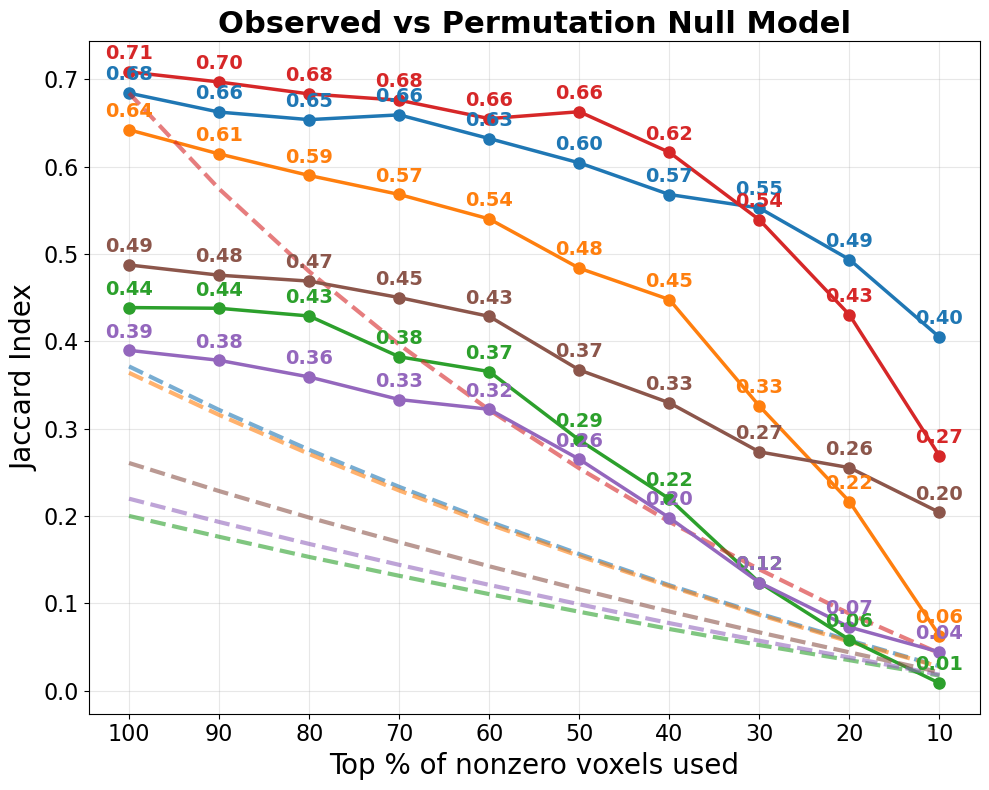

In [77]:
import pickle
import matplotlib.pyplot as plt
import os

# Find the latest result file in the output directory
output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\JI"
files = [f for f in os.listdir(output_dir) if f.startswith("jaccard_analysis_results_") and f.endswith(".pkl")]
files.sort(reverse=True)
result_file = files[0]
result_path = os.path.join(output_dir, result_file)

with open(result_path, 'rb') as f:
    data = pickle.load(f)

results = data['results']
percentages = data['percentages']
pair_names = data['pair_names']

colors = {
    'behavioral vs cgpt3': '#1f77b4',
    'behavioral vs claude4': '#ff7f0e',
    'behavioral vs gemini2p5': '#2ca02c',
    'cgpt3 vs claude4': '#d62728',
    'cgpt3 vs gemini2p5': '#9467bd',
    'claude4 vs gemini2p5': '#8c564b'
}

plt.figure(figsize=(10, 8))
observed_handles = []
for pair in pair_names:
    color = colors.get(pair, 'black')
    observed_values = results['observed'][pair]
    perm_null_values = results['permutation_null'][pair]
    line_obs, = plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, markersize=8)
    plt.plot(percentages, perm_null_values, '--', color=color, linewidth=3, alpha=0.6)
    for x, y in zip(percentages, observed_values):
        plt.text(x, y + 0.01, f'{y:.2f}', fontsize=14, ha='center', va='bottom', color=color, fontweight='bold')
    observed_handles.append(line_obs)

# Permutation Null handle (gray dashed line)
perm_null_handle = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--', alpha=0.6)

plt.xlabel('Top % of nonzero voxels used', fontsize=20)
plt.ylabel('Jaccard Index', fontsize=20)
plt.title('Observed vs Permutation Null Model', fontsize=22, fontweight='bold')
plt.yticks(fontsize=16)
plt.xticks(percentages, fontsize=16)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Custom legend like the example
labels = [
    'behavioral vs cgpt3',
    'behavioral vs claude4',
    'behavioral vs gemini2p5',
    'cgpt3 vs claude4',
    'cgpt3 vs gemini2p5',
    'claude4 vs gemini2p5',
    'Permutation Null'
]
handles = observed_handles + [perm_null_handle]
# plt.legend(handles, labels, title='Model Comparisons', loc='upper right', frameon=True)
plt.show()

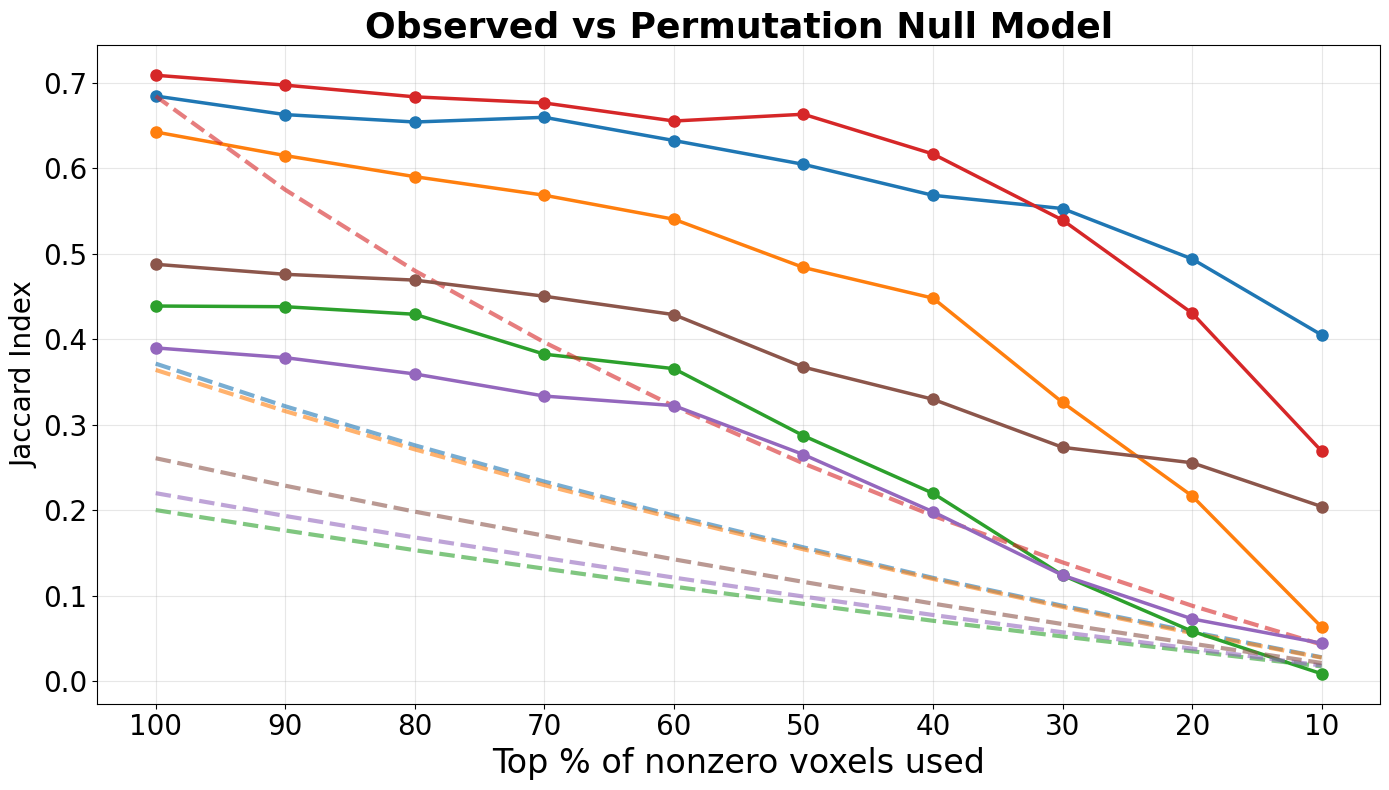

In [78]:
import pickle
import matplotlib.pyplot as plt
import os

# Find the latest result file in the output directory
output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\JI"
files = [f for f in os.listdir(output_dir) if f.startswith("jaccard_analysis_results_") and f.endswith(".pkl")]
files.sort(reverse=True)
result_file = files[0]
result_path = os.path.join(output_dir, result_file)

with open(result_path, 'rb') as f:
    data = pickle.load(f)

results = data['results']
percentages = data['percentages']
pair_names = data['pair_names']

colors = {
    'behavioral vs cgpt3': '#1f77b4',
    'behavioral vs claude4': '#ff7f0e',
    'behavioral vs gemini2p5': '#2ca02c',
    'cgpt3 vs claude4': '#d62728',
    'cgpt3 vs gemini2p5': '#9467bd',
    'claude4 vs gemini2p5': '#8c564b'
}

plt.figure(figsize=(14, 8))
observed_handles = []
for pair in pair_names:
    color = colors.get(pair, 'black')
    observed_values = results['observed'][pair]
    perm_null_values = results['permutation_null'][pair]
    line_obs, = plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, markersize=8)
    plt.plot(percentages, perm_null_values, '--', color=color, linewidth=3, alpha=0.6)
    # for x, y in zip(percentages, observed_values):
    #     plt.text(x, y + 0.01, f'{y:.2f}', fontsize=14, ha='center', va='bottom', color=color, fontweight='bold')
    observed_handles.append(line_obs)

# Permutation Null handle (gray dashed line)
perm_null_handle = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--', alpha=0.6)

plt.xlabel('Top % of nonzero voxels used', fontsize=24)
plt.ylabel('Jaccard Index', fontsize=20)
plt.title('Observed vs Permutation Null Model', fontsize=26, fontweight='bold')
plt.yticks(fontsize=20)
plt.xticks(percentages, fontsize=20)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Custom legend like the example
labels = [
    'behavioral vs cgpt3',
    'behavioral vs claude4',
    'behavioral vs gemini2p5',
    'cgpt3 vs claude4',
    'cgpt3 vs gemini2p5',
    'claude4 vs gemini2p5',
    'Permutation Null'
]
handles = observed_handles + [perm_null_handle]

plt.show()

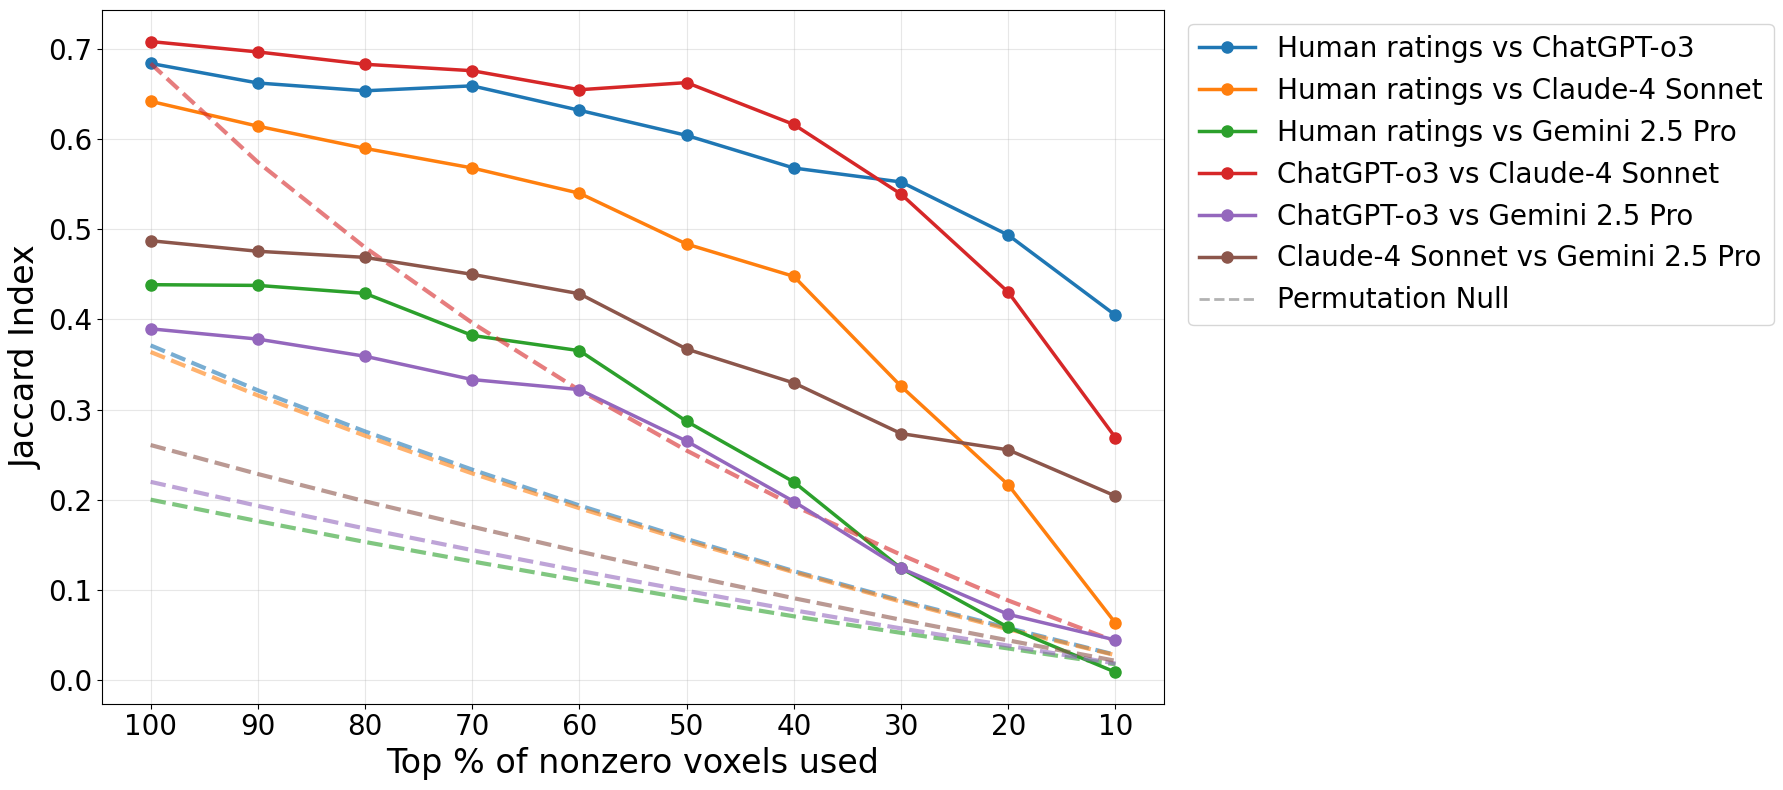

In [11]:
import pickle
import matplotlib.pyplot as plt
import os

# Find the latest result file in the output directory
output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\JI"
files = [f for f in os.listdir(output_dir) if f.startswith("jaccard_analysis_results_") and f.endswith(".pkl")]
files.sort(reverse=True)
result_file = files[0]
result_path = os.path.join(output_dir, result_file)

with open(result_path, 'rb') as f:
    data = pickle.load(f)

results = data['results']
percentages = data['percentages']
pair_names = data['pair_names']

colors = {
    'behavioral vs cgpt3': '#1f77b4',
    'behavioral vs claude4': '#ff7f0e',
    'behavioral vs gemini2p5': '#2ca02c',
    'cgpt3 vs claude4': '#d62728',
    'cgpt3 vs gemini2p5': '#9467bd',
    'claude4 vs gemini2p5': '#8c564b'
}

plt.figure(figsize=(18, 8))
observed_handles = []
for pair in pair_names:
    color = colors.get(pair, 'black')
    observed_values = results['observed'][pair]
    perm_null_values = results['permutation_null'][pair]
    line_obs, = plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, markersize=8)
    plt.plot(percentages, perm_null_values, '--', color=color, linewidth=3, alpha=0.6)
    # for x, y in zip(percentages, observed_values):
    #     plt.text(x, y + 0.01, f'{y:.2f}', fontsize=14, ha='center', va='bottom', color=color, fontweight='bold')
    observed_handles.append(line_obs)

# Permutation Null handle (gray dashed line)
perm_null_handle = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--', alpha=0.6)

plt.xlabel('Top % of nonzero voxels used', fontsize=24)
plt.ylabel('Jaccard Index', fontsize=24)
# plt.title('Observed vs Permutation Null Model', fontsize=26, fontweight='bold')
plt.yticks(fontsize=20)
plt.xticks(percentages, fontsize=20)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Custom legend like the example
labels = [
    'Human ratings vs ChatGPT-o3',
    'Human ratings vs Claude-4 Sonnet',
    'Human ratings vs Gemini 2.5 Pro',
    'ChatGPT-o3 vs Claude-4 Sonnet',
    'ChatGPT-o3 vs Gemini 2.5 Pro',
    'Claude-4 Sonnet vs Gemini 2.5 Pro',
    'Permutation Null'
]
handles = observed_handles + [perm_null_handle]
plt.legend(
    handles, labels,
    # title='Model Comparisons',
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    ncol=1,
    frameon=True,
    fontsize=20,
    title_fontsize=18
)
plt.tight_layout()
plt.show()


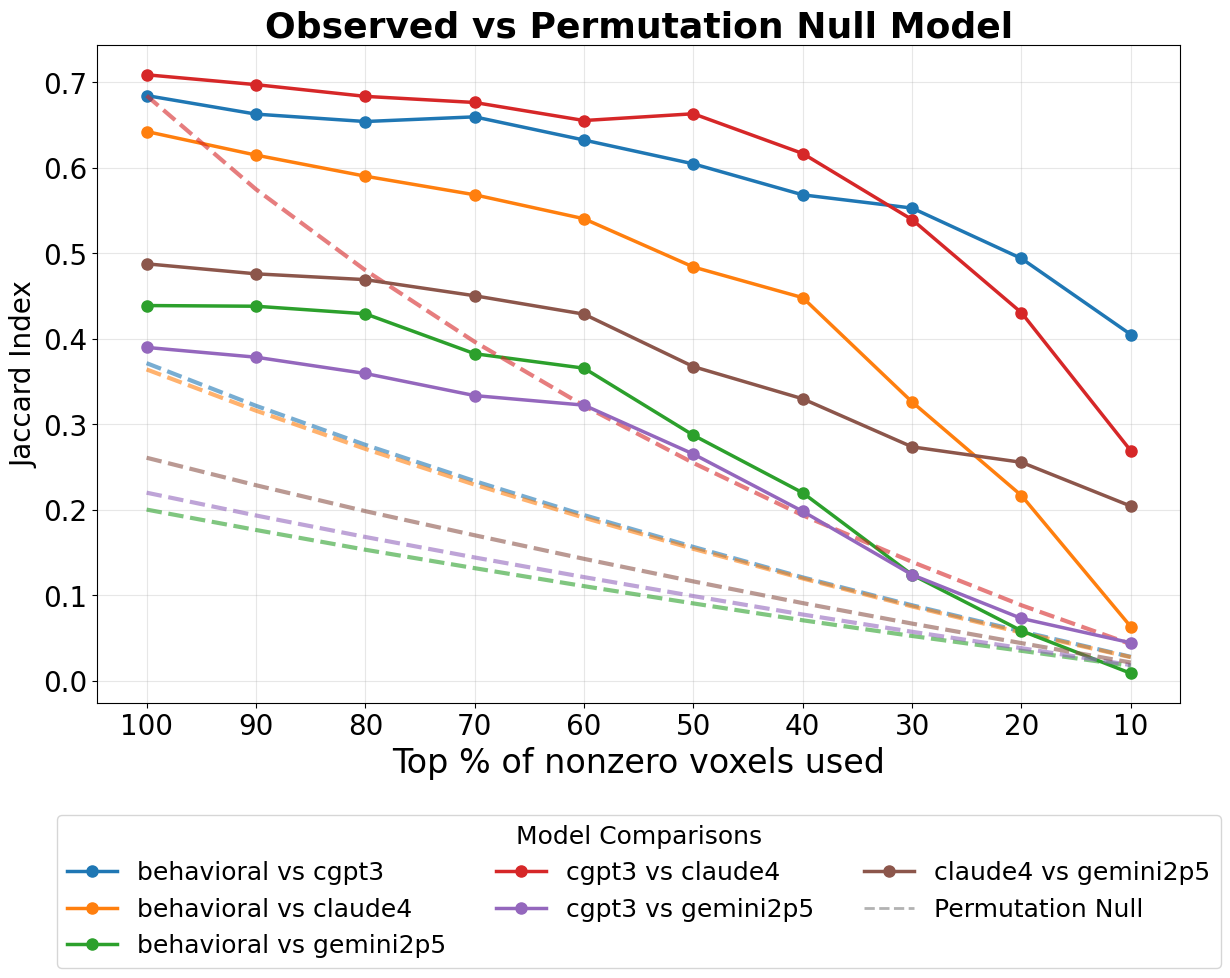

In [12]:
import pickle
import matplotlib.pyplot as plt
import os

# Find the latest result file in the output directory
output_dir = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\JI"
files = [f for f in os.listdir(output_dir) if f.startswith("jaccard_analysis_results_") and f.endswith(".pkl")]
files.sort(reverse=True)
result_file = files[0]
result_path = os.path.join(output_dir, result_file)

with open(result_path, 'rb') as f:
    data = pickle.load(f)

results = data['results']
percentages = data['percentages']
pair_names = data['pair_names']

colors = {
    'behavioral vs cgpt3': '#1f77b4',
    'behavioral vs claude4': '#ff7f0e',
    'behavioral vs gemini2p5': '#2ca02c',
    'cgpt3 vs claude4': '#d62728',
    'cgpt3 vs gemini2p5': '#9467bd',
    'claude4 vs gemini2p5': '#8c564b'
}

plt.figure(figsize=(12, 8))
observed_handles = []
for pair in pair_names:
    color = colors.get(pair, 'black')
    observed_values = results['observed'][pair]
    perm_null_values = results['permutation_null'][pair]
    line_obs, = plt.plot(percentages, observed_values, 'o-', color=color, linewidth=2.5, markersize=8)
    plt.plot(percentages, perm_null_values, '--', color=color, linewidth=3, alpha=0.6)
    # for x, y in zip(percentages, observed_values):
    #     plt.text(x, y + 0.01, f'{y:.2f}', fontsize=14, ha='center', va='bottom', color=color, fontweight='bold')
    observed_handles.append(line_obs)

# Permutation Null handle (gray dashed line)
perm_null_handle = plt.Line2D([0], [0], color='gray', linewidth=2, linestyle='--', alpha=0.6)

plt.xlabel('Top % of nonzero voxels used', fontsize=24)
plt.ylabel('Jaccard Index', fontsize=20)
plt.title('Observed vs Permutation Null Model', fontsize=26, fontweight='bold')
plt.yticks(fontsize=20)
plt.xticks(percentages, fontsize=20)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Custom legend like the example
labels = [
    'behavioral vs cgpt3',
    'behavioral vs claude4',
    'behavioral vs gemini2p5',
    'cgpt3 vs claude4',
    'cgpt3 vs gemini2p5',
    'claude4 vs gemini2p5',
    'Permutation Null'
]
handles = observed_handles + [perm_null_handle]
plt.legend(
    handles, labels,
    title='Model Comparisons',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=True,
    fontsize=18,
    title_fontsize=18
)
plt.show() 